[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maxischa/datacamp_test/blob/main/bloc4_ml/cours/seance2_cours.ipynb)

# Séance 4.2 — Prédire une décision — qui va résilier ?

**Cours** · durée : 2h (≈50 min de cours, ≈50 min d'exercices)

> ⚠️ **Avant de taper quoi que ce soit :** *Fichier → Enregistrer une copie dans Drive*. Sinon votre travail sera perdu en fermant l'onglet.
>
> 📱 Sur tablette, faites d'abord les réglages de [Bien démarrer](https://github.com/maxischa/datacamp_test/blob/main/ressources/setup_tablette.md).

## Objectifs

À la fin de cette séance, vous saurez :

- transformer des colonnes de texte en variables utilisables par un modèle
- ajuster une régression logistique et lire une probabilité de départ
- lire une matrice de confusion et nommer les deux façons de se tromper
- calculer et interpréter justesse, précision, rappel et F1
- expliquer pourquoi la justesse est un piège sur des données déséquilibrées
- choisir un seuil de décision à partir d'un coût, pas d'une habitude

## Sommaire du cours

1. **De la régression linéaire à la régression logistique**
   - 1.1 Continuer à faire de l'apprentissage supervisé
   - 1.2 Passer d'une cible continue à une cible binaire
   - 1.3 Comprendre les conséquences statistiques et interprétatives
   - 1.4 Une application : prédire la résiliation d'un abonné
   - 1.5 Comprendre pourquoi la régression linéaire n'est pas adaptée
   - 1.6 Nettoyer et explorer les données
2. **Préparer les variables pour le modèle**
   - 2.1 Transformer les variables textuelles en nombres
   - 2.2 Choisir une modalité de référence
   - 2.3 Comprendre pourquoi cette préparation n'était pas nécessaire en séance 4.1
3. **Ajuster une régression logistique**
   - 3.1 Constituer les jeux d'apprentissage et de test
   - 3.2 Ajuster le modèle logistique
   - 3.3 Lire une probabilité de départ
4. **Évaluer une prédiction binaire**
   - 4.1 Passer des probabilités aux classes prédites
   - 4.2 Lire la matrice de confusion
   - 4.3 Calculer justesse, précision, rappel et F1
   - 4.4 Interpréter les quatre mesures
   - 4.5 Comprendre le score F1
5. **Comprendre le piège de la justesse**
   - 5.1 Comparer le modèle à une prédiction naïve
   - 5.2 Interpréter des données déséquilibrées
6. **Choisir un seuil comme décision de gestion**
   - 6.1 Transformer une probabilité en décision
   - 6.2 Comparer plusieurs seuils
   - 6.3 Relier le seuil aux coûts des erreurs
   - 6.4 Interpréter le gain économique
7. **Reconnaître deux erreurs de classification**
   - 7.1 L'erreur bruyante : fournir du texte au modèle
   - 7.2 L'erreur silencieuse : se fier à la seule justesse
8. **Synthèse**
   - 8.1 Aide-mémoire des commandes
   - 8.2 La matrice de confusion
   - 8.3 Les quatre mesures
   - 8.4 Les trois phrases à retenir

## 1. De la régression linéaire à la régression logistique

### 1.1 Continuer à faire de l'apprentissage supervisé

Dans la séance précédente, nous avons utilisé une régression linéaire pour
prédire le chiffre d'affaires d'une commande. Nous disposions d'observations
pour lesquelles les variables explicatives `X` et la réponse `y` étaient
connues, puis nous avons séparé les données en jeux d'apprentissage et de test.
Nous étions donc déjà dans le cadre de l'**apprentissage supervisé**.

Nous restons dans ce même cadre. Le modèle apprendra toujours une relation à
partir d'exemples étiquetés, puis sera évalué sur des observations qu'il n'a
jamais vues. Ce qui change n'est pas le principe de l'apprentissage, mais la
**nature de la réponse à prédire**.

### 1.2 Passer d'une cible continue à une cible binaire

Avec la régression linéaire, la cible était **continue** : le chiffre
d'affaires pouvait prendre de nombreuses valeurs en euros. Dans ce cours, la
cible représente un **choix binaire** :

- `churn = 1` si l'abonné résilie ;
- `churn = 0` s'il reste.

Chaque ligne décrit toujours une observation et ses caractéristiques, mais `y`
possède désormais seulement deux modalités. Nous ne cherchons donc plus
directement à prévoir un montant : nous voulons estimer la **probabilité
d'appartenir à la classe 1**, puis transformer cette probabilité en décision.

La régression logistique porte le mot « régression », mais elle est utilisée
ici comme un modèle de **classification supervisée**.

### 1.3 Comprendre les conséquences statistiques et interprétatives

Le passage d'une cible continue à une cible binaire modifie à la fois
l'application statistique et l'interprétation du modèle :

| | Régression linéaire | Régression logistique |
|---|---|---|
| **Cible** | valeur continue | classe 0 ou 1 |
| **Sortie du modèle** | valeur numérique prédite | probabilité comprise entre 0 et 1 |
| **Forme du modèle** | droite ou plan | courbe logistique en forme de S |
| **Décision** | la valeur prédite est utilisée directement | un seuil transforme la probabilité en classe |
| **Évaluation** | MAE, RMSE et R² | matrice de confusion, justesse, précision, rappel et F1 |
| **Lecture des coefficients** | variation directe de `y` pour une unité de `X` | variation des *log-odds*, souvent traduite en rapport de chances ou en probabilité |

La régression linéaire pouvait produire n'importe quelle valeur réelle. Pour
une décision binaire, cela conduirait notamment à des « probabilités »
inférieures à 0 ou supérieures à 1. La régression logistique transforme au
contraire un score linéaire en une probabilité valide grâce à la fonction
logistique :

$$
P(y=1\mid X)=\frac{1}{1+e^{-(\beta_0+\beta_1X_1+\cdots+\beta_pX_p)}}.
$$

Un coefficient logistique ne se lit donc pas comme « `y` augmente directement
de tant d'unités ». Son effet sur la probabilité dépend du point de départ.
Enfin, le modèle ne décide pas seul : le passage de la probabilité à
« résilie » ou « reste » dépend d'un **seuil**, dont le choix doit refléter le
coût des différentes erreurs.

### 1.4 Une application : prédire la résiliation de 7 043 abonnés

Nouveau terrain : un opérateur télécom. Chaque ligne est un abonné, et la
colonne `churn` vaut **1 s'il a résilié**, 0 sinon.

> *« Qui va partir le mois prochain — et qui faut-il appeler ? »*

C'est une **prédiction binaire** : la réponse n'est plus un nombre, c'est une
décision.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Affichage adapte aux petits ecrans
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 80)

# Les donnees sont lues directement depuis le web : rien a telecharger
BASE = "https://raw.githubusercontent.com/maxischa/datacamp_test/main/bloc4_ml/data/"

In [ ]:
tel = pd.read_csv(BASE + "churn.csv")   ## une ligne = un abonne

print(tel.shape)
tel.head(3)

### 1.5 Comprendre pourquoi la régression linéaire n'est pas adaptée à une cible binaire

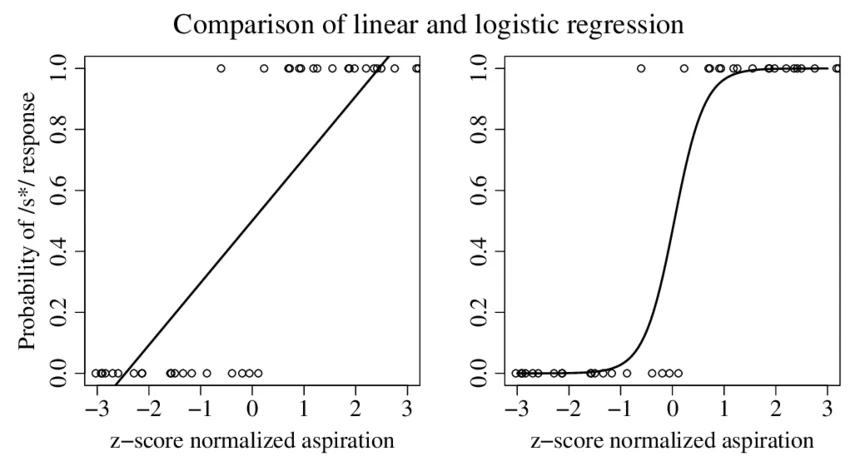

### 1.6 Nettoyer et explorer les données

Une fois le choix fait, on nettoie la base de données.

In [ ]:
tel.dtypes

`total` est arrivé en texte.

In [ ]:
tel["total"] = pd.to_numeric(tel["total"], errors="coerce")   ## coerce -> NaN
print(tel["total"].isna().sum(), "valeurs vides ->", end=" ")   ## on VERIFIE

tel = tel.dropna(subset=["total"])   ## cette colonne seulement
print(len(tel), "abonnes conserves")

De plus, onze nouveaux abonnés n'ont pas encore de facture cumulée.

In [ ]:
# La moyenne d'une colonne de 0 et de 1, c'est la proportion de 1
print("taux de resiliation :", round(100 * tel["churn"].mean(), 1), "%")

(tel.groupby("contrat")["churn"].mean() * 100).round(1)   ## par type de contrat

**42,7 % chez les abonnés au mois, 2,8 % chez ceux engagés deux ans.**

Gardez ce tableau en tête : la séance 4.3 y reviendra pour en faire une
recommandation chiffrée.

## 2. Préparer les variables pour le modèle

### 2.1 Transformer les variables textuelles en nombres

Un modèle multiplie des nombres : il ne sait pas quoi faire de `"mensuel"`.
`get_dummies` transforme chaque modalité en une colonne 0/1.

In [ ]:
y = tel["churn"]   ## la cible : 1 = parti
X = pd.get_dummies(tel.drop(columns=["churn"]), drop_first=True)

print(X.shape[1], "colonnes apres transformation")   ## 9 -> 14
list(X.columns)

### 2.2 Choisir une modalité de référence

> 💡 `drop_first=True` supprime une modalité par variable, celle qui devient
> la **référence** — exactement comme la modalité absente du tableau de
> régression de la séance 3.4. Si ce n'est ni `un_an` ni `deux_ans`, c'est
> forcément `mensuel` : la troisième colonne n'apporterait rien.

### 2.3 Comprendre pourquoi cette préparation n'était pas nécessaire en séance 4.1

Question légitime : en 4.1, on n'a jamais appelé `get_dummies`. Pourquoi
maintenant ?

Parce qu'en 4.1, **les deux variables d'entrée étaient déjà des nombres** :
`qte` et `nart` se comptent. Ici, `contrat`, `internet` et `paiement`
contiennent du texte.

La règle est la même dans les deux cas, et elle vaut pour **tout** modèle de
scikit-learn — régression linéaire comprise : un modèle multiplie chaque
variable par un coefficient, et on ne multiplie pas `"mensuel"` par 0,4. Ce
n'est pas la logistique qui exige `get_dummies`, c'est le fait d'avoir du
texte en entrée. Si la séance 4.1 avait voulu utiliser la colonne `pays`,
elle aurait dû faire exactement la même chose.

## 3. Ajuster une régression logistique

### 3.1 Constituer les jeux d'apprentissage et de test

Nous séparons les abonnés avant d'ajuster le modèle afin de conserver un jeu de
test totalement indépendant.

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)   ## stratify : voir plus bas

# stratify=y : garder le meme taux de resiliation des deux cotes
print(round(100 * y_tr.mean(), 1), "% de churn en apprentissage |",
      round(100 * y_te.mean(), 1), "% en test")

### 3.2 Ajuster le modèle logistique

Le pipeline standardise d'abord les variables numériques, puis estime la
régression logistique uniquement sur le jeu d'apprentissage.

In [ ]:
# StandardScaler d'abord : l'anciennete va de 0 a 72, la facture cumulee
# de 18 a 8 700. Sans mise a l'echelle, l'optimisation converge mal.
modele = make_pipeline(StandardScaler(), LogisticRegression())
modele.fit(X_tr, y_tr)

# predict_proba renvoie deux colonnes : [proba de rester, proba de partir]
proba = modele.predict_proba(X_te)[:, 1]   ## l'indice 1 : la proba de partir
print("probabilite de depart des 5 premiers :", proba[:5].round(3))

### 3.3 Lire une probabilité de départ

La régression logistique ne répond pas « part » ou « reste » : elle donne une
**probabilité de départ**. C'est nous qui déciderons à partir de quel niveau
on agit — et ce choix est le sujet de la fin de séance.

## 4. Évaluer une prédiction binaire

### 4.1 Passer des probabilités aux classes prédites

En séance 4.1, l'erreur se mesurait en euros. Ici, il n'y a plus d'euros : une
prédiction est **juste ou fausse**. Mais il y a **deux façons** d'avoir faux,
et elles ne coûtent pas la même chose.

Croisons ce que le modèle a prédit avec ce qui s'est réellement passé.

In [ ]:
pred = modele.predict(X_te)   ## predict tranche a 0,50 par defaut

pd.DataFrame(confusion_matrix(y_te, pred),
             index=["reste vraiment", "part vraiment"],
             columns=["predit reste", "predit part"])

### 4.2 Lire la matrice de confusion

|  | prédit : reste | prédit : part |
|---|---|---|
| **reste vraiment** | 1 377 — **vrai négatif** | 172 — **faux positif** |
| **part vraiment** | 255 — **faux négatif** | 306 — **vrai positif** |

- Un **faux positif** coûte un appel de rétention : 15 €.
- Un **faux négatif** coûte un client : il s'en va sans qu'on ait rien tenté.

Deux erreurs, deux additions très différentes. Aucune mesure unique ne peut
résumer ça — d'où les quatre qui suivent.

### 4.3 Calculer justesse, précision, rappel et F1

| Mesure | On divise | Elle répond à |
|---|---|---|
| **justesse** | (VN + VP) / total | quelle part de mes prédictions est bonne ? |
| **précision** | VP / (VP + FP) | parmi ceux que j'**appelle**, combien partaient vraiment ? |
| **rappel** | VP / (VP + FN) | parmi ceux qui **partent**, combien ai-je récupéré ? |
| **F1** | 2 × précision × rappel / (précision + rappel) | les deux tiennent-elles ensemble ? |

La précision se divise par ceux qu'on **appelle**, le rappel par ceux qui
**partent**. C'est tout ce qui les sépare, et c'est ce qui change tout.

In [ ]:
print("justesse  :", round(accuracy_score(y_te, pred), 3))
print("precision :", round(precision_score(y_te, pred), 3))
print("rappel    :", round(recall_score(y_te, pred), 3))
print("F1        :", round(f1_score(y_te, pred), 3))

### 4.4 Interpréter les quatre mesures

- **Justesse 0,798** : quatre prédictions sur cinq sont bonnes. Gardez ce
  chiffre, la section suivante le déconstruit.
- **Précision 0,64** : sur dix abonnés contactés, six allaient vraiment
  partir — quatre appels pour rien.
- **Rappel 0,545** : nous retrouvons un partant sur deux. L'autre moitié s'en
  va sans que personne ne l'appelle.
- **F1 0,589** : les deux précédentes résumées en un nombre.

### 4.5 Comprendre pourquoi le F1 n'est pas une moyenne ordinaire

Précision et rappel se manipulent facilement, mais **en sens contraire** : pour
avoir un rappel de 1, il suffit d'appeler tout le monde. La précision tombe
alors à 0,27 — la proportion de partants dans le fichier.

Une moyenne ordinaire donnerait à cette stratégie absurde (1 + 0,27) / 2 =
**0,63**, mieux que notre modèle. Le F1, lui, la note **0,42** : il est tiré
vers le bas par la plus faible des deux.

> 💡 **Retenez ça du F1 :** il ne récompense pas un modèle qui sacrifie une
> mesure pour gonfler l'autre. Il faut être bon **des deux côtés**.

## 5. Comprendre le piège de la justesse

### 5.1 Comparer le modèle à une prédiction naïve

79,8 % de bonnes réponses : de quoi présenter le projet en comité.

**Avant ça, une question :** quelle justesse obtiendrait un modèle qui prédit
que *personne* ne part ?

In [ ]:
# Le modele le plus bete du monde : il repond toujours "reste"
print("toujours predire 'reste' :", round(100 * (1 - y_te.mean()), 1), "%")   ## 73,4

### 5.2 Interpréter des données déséquilibrées

**73,4 %.** Notre modèle ne gagne que **six points** sur un modèle qui ne fait
strictement rien — et qui, lui, ne sauverait aucun client.

C'est le piège des données **déséquilibrées** : quand une classe pèse trois
quarts du fichier, la justesse récompense le fait de toujours parier dessus.

Les trois autres mesures ne s'y laissent pas prendre. Un modèle qui ne prédit
jamais aucun départ n'a **aucun** vrai positif : sa précision, son rappel et
son F1 valent tous **zéro**. C'est ce qu'on vérifiera en fin de séance.

> ⚠️ **Ne jugez jamais une classification sur la seule justesse.** Demandez
> systématiquement trois choses : le score du modèle nul, la matrice de
> confusion, et le rappel.

## 6. Choisir un seuil comme décision de gestion

### 6.1 Transformer une probabilité en décision

Un **seuil** est une valeur à partir de laquelle un modèle transforme une
probabilité en une décision.

Par exemple, une régression logistique peut estimer qu'un client a **70 % de
chances d'acheter**. Pour obtenir une prédiction binaire — « achète » ou
« n'achète pas » — on choisit souvent un seuil de 50 % :

$$
\widehat{Y}=
\begin{cases}
1 & \text{si } \widehat{P}(Y=1)\geq 0{,}5 \\
0 & \text{si } \widehat{P}(Y=1)<0{,}5
\end{cases}
$$

Le modèle prédit alors :

- une probabilité de 70 % : **« achète »** ;
- une probabilité de 30 % : **« n'achète pas »**.

### 6.2 Comparer plusieurs seuils

`predict` a tranché **0,50** par défaut. Rien ne l'impose. Regardons ce que
d'autres seuils donnent.

Une seule tournure sert à toute la fin de la séance, et vous la connaissez
depuis la séance 2.1 : **comparer à une valeur ne rend pas un nombre, mais une
réponse `True`/`False` par ligne.** `proba > 0.20` fabrique donc 2 110
réponses, une par abonné du jeu de test. Deux opérations se branchent dessus :

| Ce qu'on écrit | Ce qu'on obtient |
|---|---|
| `(proba > 0.20).astype(int)` | les `True` deviennent `1`, les `False` `0` : **la décision** |
| `(proba > 0.20).sum()` | le nombre de `True`, donc **le nombre d'appels à passer** |

`.astype(int)` convertit, `.sum()` compte — c'est le même `.sum()` que le
`sale.duplicated().sum()` de la séance 2.2, et pour la même raison : un `True`
vaut 1.

In [ ]:
print("probabilites    :", proba[:5].round(2))
print("decision a 0,50 :", (proba > 0.50).astype(int)[:5])   ## 0 = on n'appelle pas
print("decision a 0,20 :", (proba > 0.20).astype(int)[:5])   ## deux basculent

# Et pour verifier : combien de decisions identiques a celles de predict ?
identiques = ((proba > 0.50).astype(int) == pred).sum()
print(identiques, "decisions identiques a predict, sur", len(pred))

Les deux premiers abonnés basculent entre 0,50 et 0,20 : à 21 % et 37 % de
risque, on ne les appelait pas, maintenant on les appelle.

Et les deux dernières lignes disent l'essentiel : **2 110 décisions sur 2 110**
identiques à celles de `predict`. Autrement dit, `predict` ne fait **rien
d'autre** que `(proba > 0.50)`. Changer ce nombre, c'est lui reprendre une
décision qu'il prenait à notre place.

> ⚠️ **« Écrivez `.query()`, jamais des crochets » — la promesse du bloc 2 tient
> toujours.** `.query()` interroge les **colonnes d'un tableau**, et il n'y a
> plus de tableau ici : `proba` est une suite de 2 110 nombres produite par le
> modèle, `y_te` une colonne mise de côté avant l'apprentissage. Ni l'une ni
> l'autre n'est une colonne de `X_te`. La comparaison directe est donc la seule
> écriture disponible — et c'est exactement le cas pour lequel on vous l'avait
> montrée en 2.1.

In [ ]:
for seuil in [0.5, 0.4, 0.3, 0.2]:
    p = (proba > seuil).astype(int)   ## True/False -> 1/0
    print("seuil", seuil,
          ": rappel", round(recall_score(y_te, p), 2),
          " precision", round(precision_score(y_te, p), 2),
          " F1", round(f1_score(y_te, p), 2),
          " contacts", p.sum())

### 6.3 Relier le seuil aux coûts des erreurs

Baisser le seuil retrouve plus de partants (rappel ↑) au prix de plus
d'appels inutiles (précision ↓). Le F1, qui tient les deux, bouge à peine :
de 0,59 à 0,62. **Aucun des réglages n'est « le bon » en soi** — cela dépend
de ce que coûte chaque erreur.

Le seuil de 50 % n'est toutefois pas obligatoire. Il dépend du coût des
erreurs.

Dans un dépistage médical, on peut choisir un seuil faible, par exemple 20 %.
Davantage de patients seront considérés comme potentiellement malades. On
détectera plus de personnes réellement malades, mais on créera aussi davantage
de fausses alertes.

À l'inverse, pour envoyer une offre promotionnelle coûteuse, une entreprise
peut retenir un seuil de 80 %. Elle ne ciblera que les clients ayant une forte
probabilité d'acheter. Elle réduira les dépenses inutiles, mais risque
d'ignorer certains acheteurs potentiels.

Il nous faut donc, dans notre cas, chiffrer.

#### 6.3.1 Chiffrer l'arbitrage économique

On souhaite maintenant exprimer cette analyse statistique en une interprétation
économique qui parle aux personnes décisionnaires de l'entreprise de
télécommunication. Pour cela, on exprime l'arbitrage en termes monétaires. Pour
ce faire, on réalise un calcul dit « back of the envelope », ou calcul en coin
de table, pour donner une estimation grossière qui quantifie de façon
intelligible notre analyse.

- un appel de rétention coûte **15 €**
- un client retenu rapporte **300 €** de marge sur l'année
- une relance convainc environ **30 %** des partants contactés

Le calcul demande un comptage qu'on n'a pas encore écrit : **parmi les abonnés
qu'on appelle, combien partaient vraiment ?** Deux conditions à la fois, sur
deux objets différents — `p`, notre décision, et `y_te`, la vérité. On les
combine avec **`&`**, qui compare les deux colonnes ligne à ligne et ne laisse
`True` que là où les deux le sont.

| Ce qu'on écrit | Ce qu'on compte |
|---|---|
| `(p == 1).sum()` | les abonnés qu'on appelle |
| `((p == 1) & (y_te == 1)).sum()` | ceux qu'on appelle **et** qui partaient vraiment |

> ⚠️ **Chaque condition va entre parenthèses.** En Python, `&` passe avant `==` :
> sans elles, `p == 1 & y_te == 1` ne calcule pas ce que vous croyez, et ne
> prévient pas.

Enfin, ce calcul est **le même à chaque seuil** ; seul le seuil change. C'est
exactement ce à quoi sert une **fonction** : écrire le calcul une fois, lui
donner un nom, le rejouer autant de fois qu'on veut.

| L'élément | Ce qu'il fait |
|---|---|
| `def gain(seuil):` | on baptise le calcul `gain`, et on annonce qu'il attend un **paramètre**, `seuil` |
| le corps **décalé** | les lignes du calcul ; elles ne s'exécutent qu'au moment de l'appel |
| `return ...` | ce que la fonction **rend** à qui l'appelle |
| `gain(0.50)` | l'appel : `seuil` vaut 0,50 le temps du calcul, et on récupère un nombre |

> 💡 Rien de neuf sous le capot : `round()`, `len()` et `f1_score()` sont des
> fonctions, et vous en appelez depuis la séance 1.1. La nouveauté, c'est que
> celle-ci, vous l'écrivez. Sans `return`, la fonction tourne et ne rend rien.

In [ ]:
# Le calcul, ecrit une fois : d'un appel a l'autre, seul le seuil change
def gain(seuil):
    p = (proba > seuil).astype(int)            ## la decision a ce seuil
    vrais = ((p == 1) & (y_te == 1)).sum()     ## appeles ET reellement partants
    return vrais * 0.30 * 300 - p.sum() * 15   ## 30 % convaincus, 15 EUR l'appel

print("au seuil de 0,50 :", round(gain(0.50)), "euros")

In [ ]:
for seuil in [0.5, 0.4, 0.3, 0.2, 0.1]:
    appels = (proba > seuil).sum()   ## .sum() compte les True, comme en 6.2
    print("seuil", seuil, ":", appels, "appels ->", round(gain(seuil)), "euros")

### 6.4 Interpréter le gain économique

**20 370 € au seuil par défaut, 28 365 € au seuil 0,20.**

Huit mille euros de plus, sans toucher une ligne du modèle. Le réglage qui
rapportait le plus n'était pas dans l'algorithme, il était dans la décision.

> ⚠️ **Ne laissez jamais `predict` choisir à votre place.** Son seuil de 0,50
> est une convention informatique, pas un arbitrage économique. Dès qu'une
> erreur coûte plus cher que l'autre, le bon seuil se calcule.

Le seuil ne modifie donc pas les probabilités calculées par le modèle. Il
modifie uniquement la manière dont elles sont converties en décisions. Son
choix détermine notamment l'équilibre entre les **faux positifs** et les
**faux négatifs**.

## 7. Reconnaître deux erreurs de classification

### 7.1 L'erreur bruyante : fournir du texte au modèle

In [ ]:
LogisticRegression().fit(tel.drop(columns=["churn"]), y)   ## sans dummies

Dernière ligne :

```
ValueError: could not convert string to float: 'mensuel'
```

On a donné les colonnes de texte telles quelles. Il manque le `get_dummies`.

### 7.2 L'erreur silencieuse : se fier à la seule justesse

In [ ]:
nul = pd.Series(0, index=y_te.index)   ## "personne ne part", jamais

print("justesse :", round(100 * accuracy_score(y_te, nul), 1), "%")
print("rappel   :", round(recall_score(y_te, nul), 3))
print("F1       :", round(f1_score(y_te, nul), 3))

**73,4 % de justesse, un rappel de 0, un F1 de 0.**

Un modèle qui ne prédit jamais aucun départ affiche un chiffre parfaitement
présentable. Rien dans ce 73,4 % ne dit qu'il est inutile — et c'est
exactement pour ça qu'on ne le regarde jamais seul.

> ⚠️ **Devant tout modèle de classification, exigez quatre choses :** le score
> du modèle nul, la matrice de confusion, le rappel et le F1. Une justesse
> seule ne veut rien dire.

---

## 8. Synthèse

### 8.1 Aide-mémoire des commandes

| Vous voulez... | La commande |
|---|---|
| du texte en colonnes numériques | `pd.get_dummies(X, drop_first=True)` |
| enchaîner mise à l'échelle et modèle | `make_pipeline(StandardScaler(), LogisticRegression())` |
| une décision (0 ou 1) | `m.predict(X_te)` |
| une **probabilité** | `m.predict_proba(X_te)[:, 1]` |
| une décision à partir d'une probabilité | `(proba > 0.20).astype(int)` |
| compter ceux qu'on appelle **et** qui partaient | `((p == 1) & (y_te == 1)).sum()` |
| écrire un calcul une fois et le rejouer | `def gain(seuil): ... return ...` |
| la matrice de confusion | `confusion_matrix(y_te, pred)` |
| la part de vrais parmi les prédits partants | `precision_score(y_te, pred)` |
| la part de partants retrouvés | `recall_score(y_te, pred)` |
| les deux à la fois, en un seul nombre | `f1_score(y_te, pred)` |

### 8.2 La matrice de confusion, en clair

|  | prédit : reste | prédit : part |
|---|---|---|
| **reste vraiment** | vrai négatif — bien vu | **faux positif** : un appel pour rien |
| **part vraiment** | **faux négatif** : client perdu sans rien tenter | vrai positif — bien vu |

### 8.3 Les quatre mesures

| Mesure | Ce qu'elle divise | Ce qu'elle répond |
|---|---|---|
| justesse | (VN + VP) / total | quelle part de mes prédictions sont bonnes ? |
| précision | VP / (VP + FP) | parmi ceux que j'appelle, combien partaient vraiment ? |
| rappel | VP / (VP + FN) | parmi ceux qui partent, combien ai-je retrouvés ? |
| F1 | 2 × précision × rappel / (précision + rappel) | les deux se tiennent-elles ensemble ? |

### 8.4 Les trois phrases à retenir

1. **La justesse est un piège.** Prédire « personne ne part » donne 73,4 % de
   bonnes réponses, zéro client sauvé — et un F1 de 0.

2. **Précision et rappel arbitrent deux coûts différents.** Le rappel dit
   combien de partants on retrouve, la précision combien de contacts sont
   utiles. On ne maximise pas les deux ; le F1 dit où on en est des deux.

3. **Le seuil est une décision de gestion.** Le déplacer de 0,50 à 0,20 fait
   passer le gain de la campagne de 20 370 € à 28 365 € — sans changer une
   ligne du modèle.